In [1]:
import json
import csv
import argparse
import os
def parse_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def compare_testsuite_times(json_list, output_csv):

    testsuites_list = [ {suite['name']: suite for suite in json_data['testsuites']} for json_data in json_list]

    all_suite_names = set(testsuites_list[0].keys()).union(set(testsuites_list[1].keys()))
    for i in range(2, len(testsuites_list)):
        all_suite_names.union( set(testsuites_list[i].keys()) )


    test_counts = len(testsuites_list)
    with open(output_csv, 'w', newline='') as csvfile:
        fieldnames = ['suite_name', 'test_name', 'value_param'] + [str(i+1) for i in range(0, test_counts)]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

        for suite_name in all_suite_names:

            suite_list = [testsuites.get(suite_name) for testsuites in testsuites_list]

            if not all(suite_list):
                continue

            suite_tests_list = [{test['name']: test for test in suite['testsuite']} for suite in suite_list]

            all_test_names = set(suite_tests_list[0].keys()).union(set(suite_tests_list[1].keys()))
            for i in range(2, len(suite_tests_list)):
                all_test_names.union( set(suite_tests_list[i].keys()) )


            # suite_tests_list: N
            for test_name in all_test_names:

                # 检查测试名称是否都在json文件中被包含
                skip_flag = False
                fail_match_index_list = []
                for kk, _test in enumerate(suite_tests_list):
                    _test_item = _test.get(test_name, False)
                    if not _test_item:
                        fail_match_index_list.append(kk)
                        skip_flag = True
                if skip_flag == True:
                    print(f'命中测试名：{test_name}存在失败，将跳过, 失败的索引为 {fail_match_index_list} ')
                    continue

                # 检查测试参数是否一致
                skip_flag_list = []
                for kk, _test in enumerate(suite_tests_list):
                    _test_item = _test.get(test_name)
                    _value_param = _test_item.get('value_param', False)
                    skip_flag_list.append(_value_param)
                if len(set(skip_flag_list)) != 1:
                    print(f'{test_name}匹配参数列表失败，将跳过，列表为{skip_flag_list}')
                    continue

                value_param = suite_tests_list[0].get(test_name).get('value_param', '0')
                init_dict = {'suite_name': suite_name, 'test_name': test_name, 'value_param': value_param}

                for j in range(0, test_counts):
                    name_index = str(j+1)
                    current_test = suite_tests_list[j].get(test_name)
                    current_time = current_test.get('mean', '0')
                    init_dict[name_index] = current_time

                writer.writerow(init_dict)

In [2]:
save_dir_list = ['./compare_core', './compare_imgproc', './compare_calib3d', './compare_features2d']
csv_file_name_list = ['compare_core', 'compare_imgproc', 'compare_calib3d', 'compare_features2d']
json_file_name_list = ['opencv_core.json', 'opencv_imgproc.json', 'opencv_calib3d.json', 'opencv_features2d.json']
base_path_list = ['./results_k1_yrvv_all', './results_k1_nrvv_all']

def build_compare_csv(current_index):
    save_dir = save_dir_list[current_index]
    os.makedirs(save_dir, exist_ok=True)

    csv_file_name = csv_file_name_list[current_index]
    save_csv_path = os.path.join(save_dir, csv_file_name + '.csv')

    base_json_list = [
        os.path.join(path_, json_file_name_list[current_index])
        for path_ in base_path_list
    ]
    json_list = [parse_json_file(item) for item in base_json_list]

    compare_testsuite_times(json_list, save_csv_path)
    return save_dir, csv_file_name, save_csv_path

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


def csv_to_xlsx_with_compare(save_dir, csv_file_name, save_csv_path):
    df = pd.read_csv(save_csv_path)

    title = ['k1 RVV', 'k1 No RVV']
    for idx, _ in enumerate(title, start=3):
        df.columns.values[idx] = title[idx - 3]

    df[''] = None
    df['RVV VS NO RVV'] = 100 * (df.iloc[:, 4] - df.iloc[:, 3]) / df.iloc[:, 4]

    xlsx_file = os.path.join(save_dir, csv_file_name + '.xlsx')
    df.to_excel(xlsx_file, index=False, engine='openpyxl')

    print(f"成功将 '{save_csv_path}' 转换为 '{xlsx_file}'")
    return df

In [4]:
col_name_list = ['RVV VS NO RVV']

In [5]:
import matplotlib.pyplot as plt

# 设置饼状图的值区间及对应颜色
def categorize(value):
    if value <= -30:
        return '< -30'
    elif -30 < value <= -20:
        return '-30 to -20'
    elif -20 < value <= -10:
        return '-20 to -10'
    elif -10 < value <= -3:
        return '-10 to -3'
    elif -3 < value < 0:
        return '-3 to 0'
    elif 0 <= value < 3:
        return '0-3'
    elif 3 <= value < 10:
        return '3-10'
    elif 10 <= value < 20:
        return '10-20'
    elif 20 <= value < 30:
        return '20-30'
    else:
        return '>30'

colors = ['#FF0000', '#FF6666', '#FF9999', '#FFCCCC', '#FFE5E5', '#E5FFE5', '#CCFFCC', '#99FF99', '#66FF66', '#00FF00']
desired_order = ['< -30', '-30 to -20', '-20 to -10', '-10 to -3', '-3 to 0', '0-3', '3-10', '10-20', '20-30', '>30']

def draw_pie_on_axis(ax, df, csv_file_name, col_name='RVV VS NO RVV'):
    category_counts = df[col_name].apply(categorize).value_counts()
    category_counts = category_counts.reindex(desired_order, fill_value=0)
    ax.pie(category_counts, labels=category_counts.index, colors=colors, autopct='%1.1f%%', startangle=140)
    ax.set_title(csv_file_name)
    ax.axis('equal')

In [6]:
def split_by_pie_category(df, save_dir, csv_file_name):
    # 数据分离 按照饼状图分区
    for col in col_name_list:
        columns_to_exclude = col_name_list.copy()
        columns_to_exclude.remove(col)

        category_series = df[col].apply(categorize)

        for category in category_series.unique():
            filtered_data = df[category_series == category]

            if not filtered_data.empty:
                cols_to_keep = [c for c in df.columns if c not in columns_to_exclude or c == col]
                filtered_data = filtered_data[cols_to_keep]
                folder_name = os.path.join(save_dir, '饼状图区间分离数据', col.replace(' ', '_'))
                os.makedirs(folder_name, exist_ok=True)

                xlsx_output_file = os.path.join(folder_name, f"{csv_file_name}_{col.replace(' ', '_')}_{category.replace(' ', '_').replace('<', 'lt').replace('>', 'gt')}.xlsx")
                filtered_data.to_excel(xlsx_output_file, index=False, engine='openpyxl')

In [7]:
def categorize_binary(value):
    if value < 0:
        return '< 0'
    else:
        return '>0'


def split_by_zero_boundary(df, save_dir, csv_file_name):
    for col in col_name_list:
        columns_to_exclude = col_name_list.copy()
        columns_to_exclude.remove(col)

        category_series = df[col].apply(categorize_binary)

        for category in category_series.unique():
            filtered_data = df[category_series == category]

            if not filtered_data.empty:
                cols_to_keep = [c for c in df.columns if c not in columns_to_exclude or c == col]
                filtered_data = filtered_data[cols_to_keep]
                folder_name = os.path.join(save_dir, '0分界线分离数据', col.replace(' ', '_'))
                os.makedirs(folder_name, exist_ok=True)

                xlsx_output_file = os.path.join(folder_name, f"{csv_file_name}_{col.replace(' ', '_')}_{category.replace(' ', '_').replace('<', 'lt').replace('>', 'gt')}.xlsx")
                filtered_data.to_excel(xlsx_output_file, index=False, engine='openpyxl')

成功将 './compare_core/compare_core.csv' 转换为 './compare_core/compare_core.xlsx'
成功将 './compare_imgproc/compare_imgproc.csv' 转换为 './compare_imgproc/compare_imgproc.xlsx'
成功将 './compare_calib3d/compare_calib3d.csv' 转换为 './compare_calib3d/compare_calib3d.xlsx'
成功将 './compare_features2d/compare_features2d.csv' 转换为 './compare_features2d/compare_features2d.xlsx'


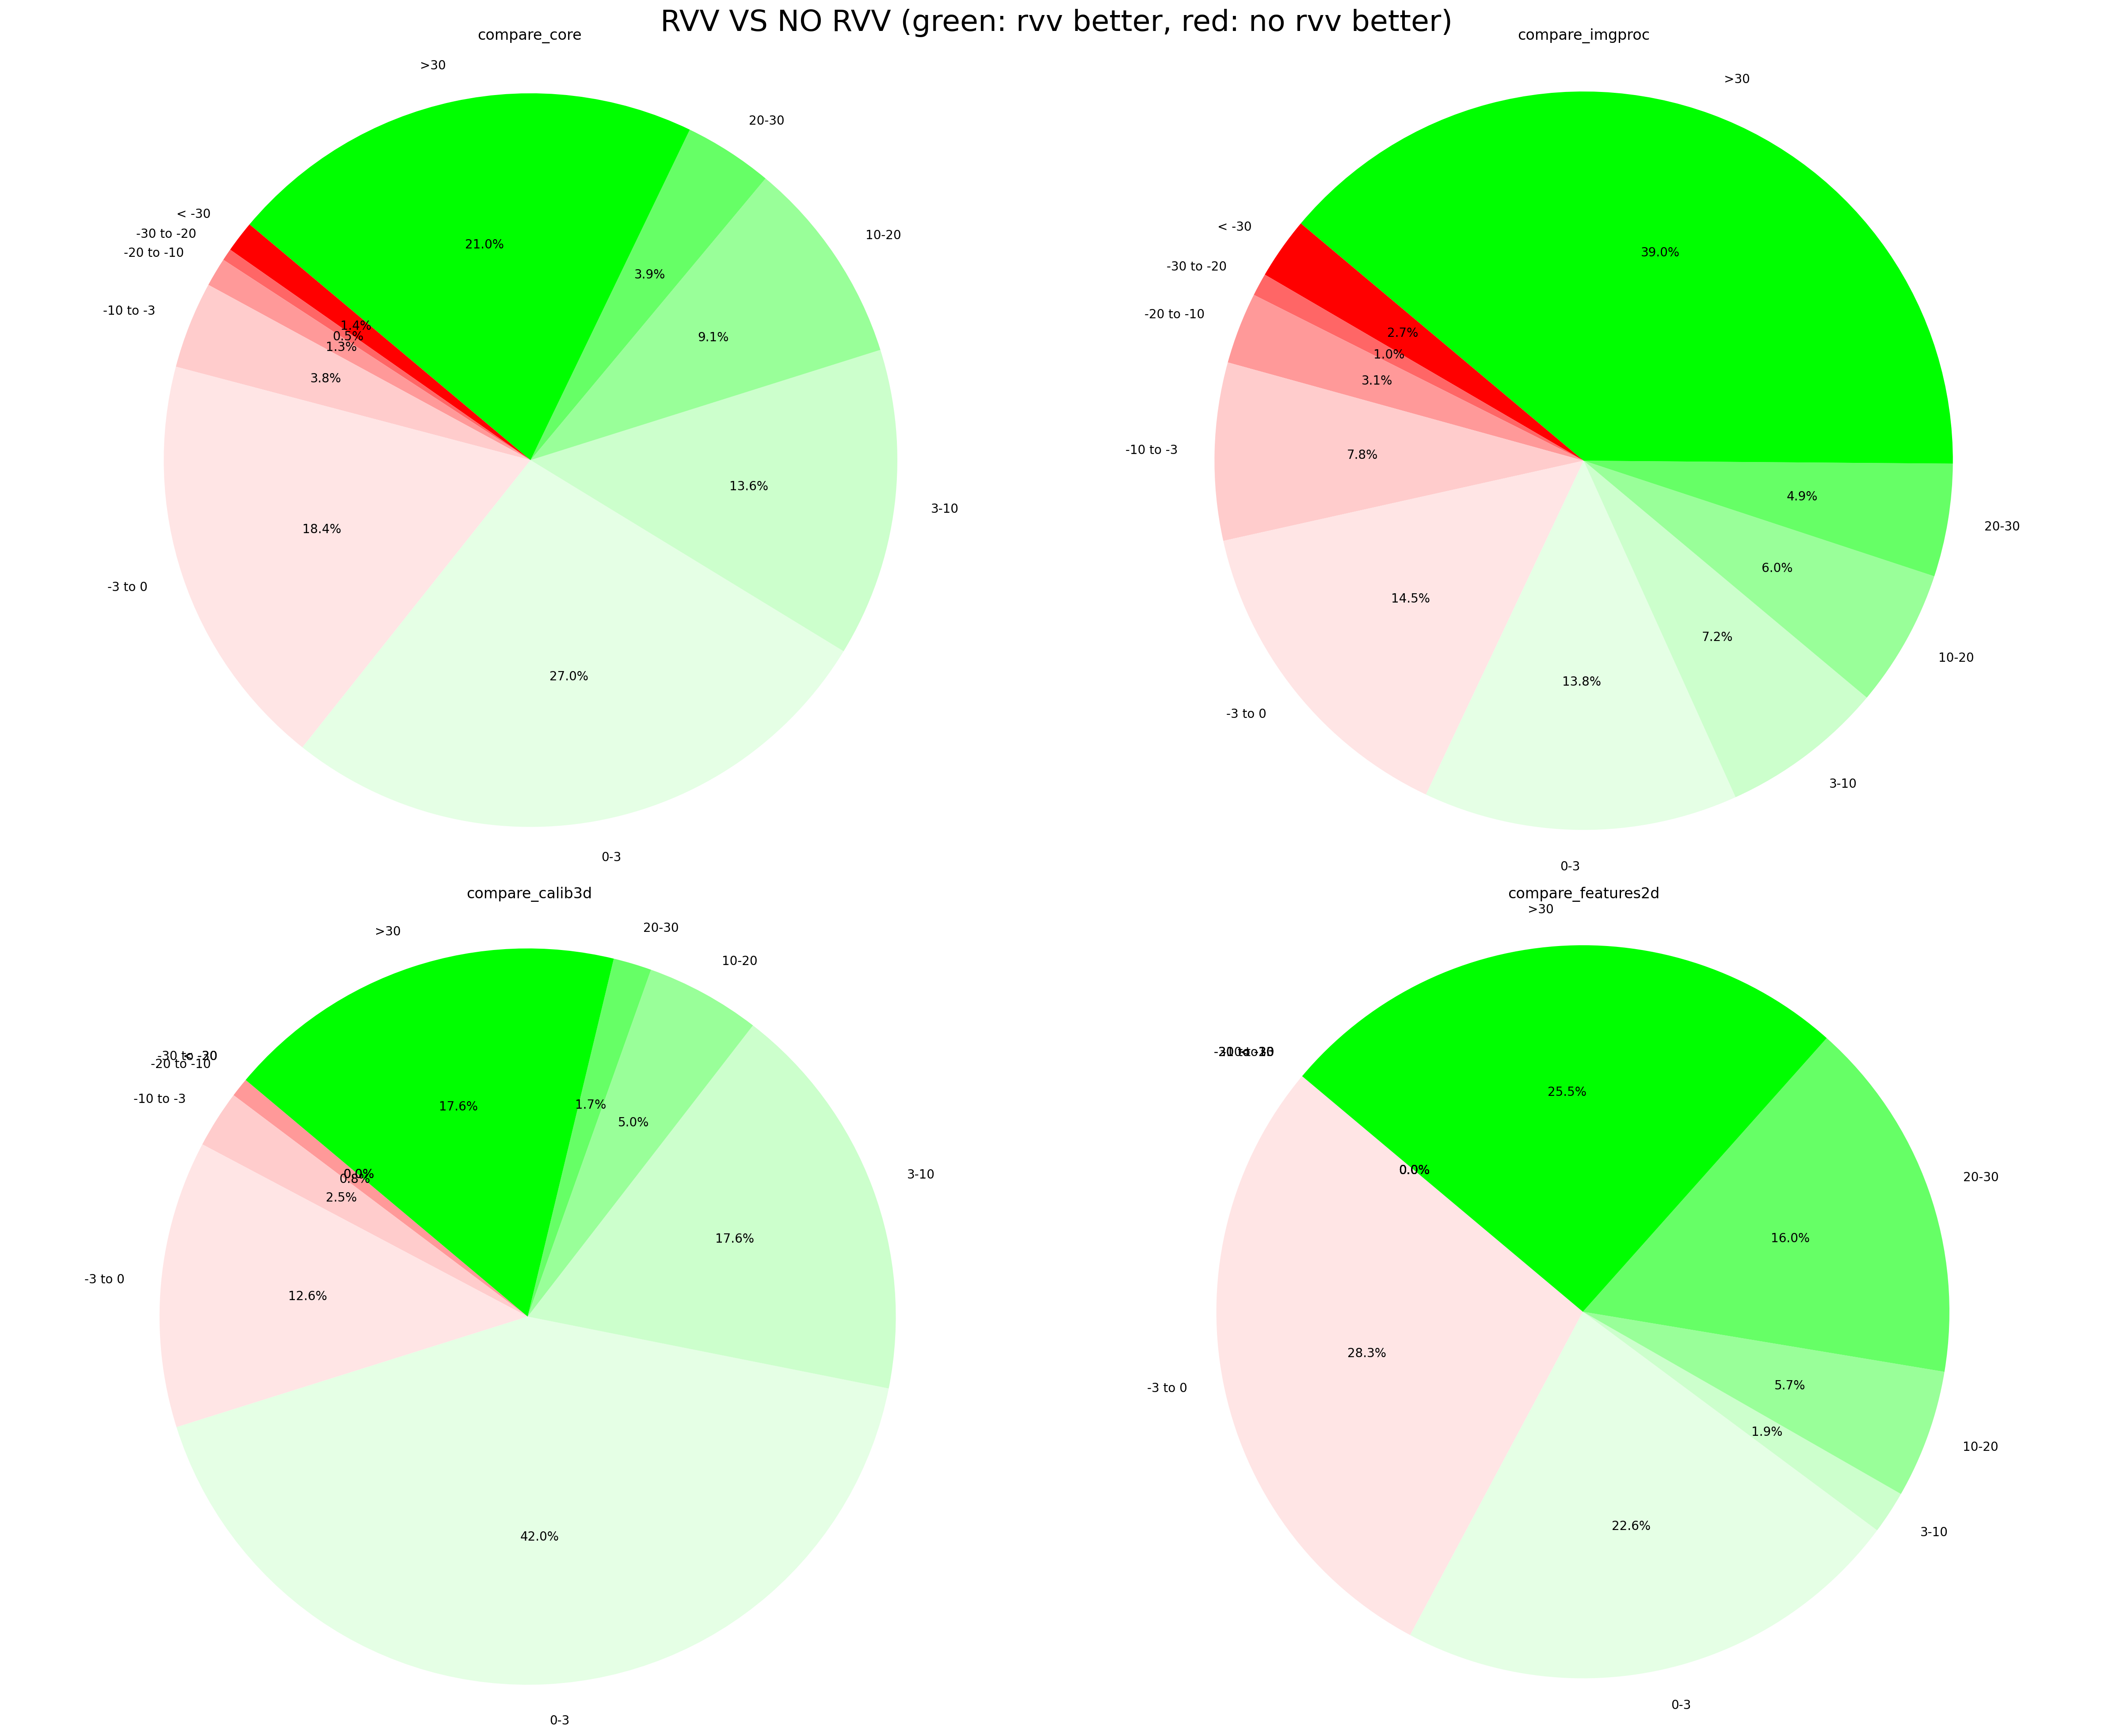

全部模块处理完成，合并饼图已保存到 ./rvv_vs_norvv_all_pie.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(24, 20), dpi=200)
axes = axes.flatten()

for current_index in range(len(csv_file_name_list)):
    save_dir, csv_file_name, save_csv_path = build_compare_csv(current_index)
    df = csv_to_xlsx_with_compare(save_dir, csv_file_name, save_csv_path)
    draw_pie_on_axis(axes[current_index], df, csv_file_name)
    split_by_pie_category(df, save_dir, csv_file_name)
    split_by_zero_boundary(df, save_dir, csv_file_name)

fig.suptitle('RVV VS NO RVV (green: rvv better, red: no rvv better)', fontsize=24)
fig.tight_layout()
combined_img_file = './rvv_vs_norvv_all_pie.png'
fig.savefig(combined_img_file, dpi=200, bbox_inches='tight')
plt.show()

print(f'全部模块处理完成，合并饼图已保存到 {combined_img_file}')